# Nhiệm vụ 2: Xây dựng mô hình SVM để nhận diện chữ viết tay từ 0 – 9

## 1. Tải thư viện và nạp dữ liệu MNIST

In [5]:
# Import thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Tải dữ liệu chữ viết tay MNIST từ Scikit-learn
digits = load_digits(n_class=10)

# Tách đặc trưng (X) và nhãn (y)
X = digits.data
y = digits.target

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia dữ liệu thành tập train và tập test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 2. Xây dựng và huấn luyện mô hình SVM

In [6]:
# Khởi tạo và huấn luyện mô hình SVM với kernel RBF
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = svm.predict(X_test)

# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of SVM (RBF Kernel): {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy of SVM (RBF Kernel): 0.98

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       0.96      1.00      0.98        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



## 3. Tối ưu hóa mô hình với GridSearchCV

In [7]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Định nghĩa lưới tham số
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# In tham số tốt nhất và độ chính xác
print("Best parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best SVM Accuracy: {accuracy_best:.2f}")

Best parameters: {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
Best SVM Accuracy: 0.98


## 4. Hiển thị một số kết quả dự đoán

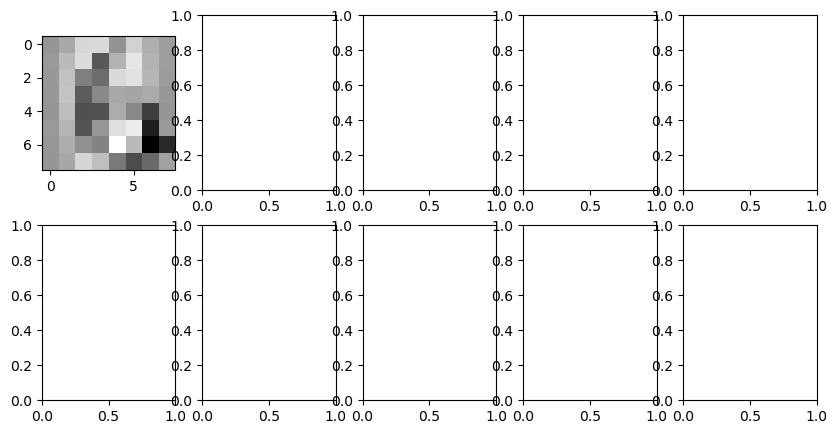

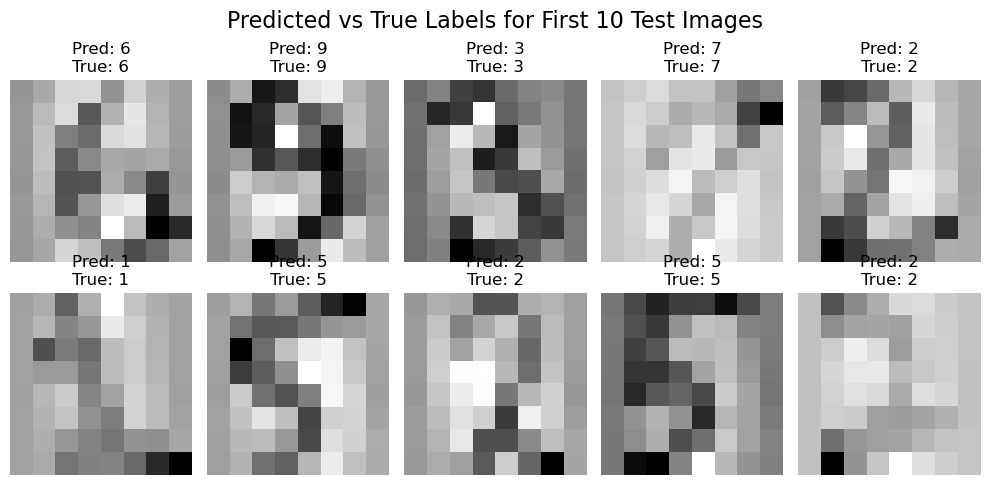

In [8]:
# Chọn 10 hình ảnh đầu tiên từ tập test để hiển thị
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap='binary')
    ax.set_title(f'Pred: {y_pred_best[i]}\nTrue: {y_test[i]}')  
    ax.axis('off')
plt.suptitle('Predicted vs True Labels for First 10 Test Images', fontsize=16)
plt.tight_layout()
plt.show()